# Neural Nets using Tensors

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



# Basic debugging functions
def print_tensor_details(tensor):
    print('instance before debug: ', tensor)
    print('shape: ', tensor.shape)
    print('size(): ', tensor.size())
    print('device: ', tensor.device)
    print('dtype: ', tensor.dtype)
    print('grad: ', tensor.grad)
    print('grad_fn: ', tensor.grad_fn)
    # print('Tensor Row/Col', tensor[:, :])
    # print('Tensor Col-2nd', tensor[:, 1])
    # print('Tensor Row-2nd', tensor[1, :])
    print('instance after debug: ', tensor)
    pass


In [2]:
# Random initializations / seeding
## 2D
tensor_rand_1_1 = torch.randn(1, 1, requires_grad=True)
## 1D
tensor_rand_1 = torch.randn(1, requires_grad=True)
## 3D
tensor_rand_1_1_1 = torch.randn(1, 1, 1, requires_grad=True)

# Now print those:
print(tensor_rand_1_1)
print(tensor_rand_1)
print(tensor_rand_1_1_1)

tensor([[-0.5153]], requires_grad=True)
tensor([0.9621], requires_grad=True)
tensor([[[-0.9210]]], requires_grad=True)


## Prepping the Data

In [3]:
# num data points
N = 10

# Assuming only 1 dimension per data-point (i.e. 1 col), and 1 predicted value per row
## In general size of X --> [N_data_points X  N_features]
## No grads required for the input
X = torch.randn(N, 1)
#print("X= ", X)

# creating data as per y = 2x + 1
## Note the dimension of W would be [N_features X N_outputs_per_row]
W_true = torch.tensor([2.0]).reshape(1, 1)

## Bias (a row-vect) will have dimensions as [1 x N_outputs_per_row]
b_true = torch.tensor([1.0]).reshape(1)

## Predicted: Y_hat will have dimension: [N_data_point X N_outputs_per_row]
Y_source = X @ W_true + b_true
#print("Y_source= ", Y_source)

## With some noise, so the regression can be understood!
Y_noise = torch.randn(N, 1) * 0.1
Y_true = Y_source + Y_noise
#print("Y_true(noise)= ", Y_true)

## Some Retro analysis on the crafted data
data_rmse = ((Y_true - Y_source) ** 2).mean().sqrt()

In [4]:
# BEGIN RAND PREDICTION AS A STRING POINT

W_predicted = torch.randn(1, 1, requires_grad=True)
b_predicted = torch.randn(1, requires_grad=True)

# W[N_features X N_output_per_row]
print("W_predicted= ", W_predicted)

# Bias --> row vector [N_output_per_row]
print("b_predicted= ", b_predicted)

W_predicted=  tensor([[-0.1477]], requires_grad=True)
b_predicted=  tensor([-0.5136], requires_grad=True)


### Just an isolated First Iteration!

          X       Y_true     Y_Hat    Step_delta   
tensor([[-0.3123,  0.2125, -0.4674,  0.6799],
        [ 0.6293,  2.3274, -0.6065,  2.9339],
        [-0.0174,  0.9956, -0.5110,  1.5066],
        [-1.8110, -2.6278, -0.2461, -2.3817],
        [-0.1504,  0.5677, -0.4913,  1.0590],
        [-0.4776,  0.0129, -0.4430,  0.4560],
        [ 0.7486,  2.5269, -0.6241,  3.1510],
        [-0.8631, -0.6725, -0.3861, -0.2864],
        [-0.3125,  0.4311, -0.4674,  0.8985],
        [ 1.3620,  3.7839, -0.7147,  4.4986]], grad_fn=<CatBackward0>)
RMSE=  2.2225453853607178
W_predicted=  -0.1476864218711853
b_predicted=  -0.5135575532913208
W_Grad= -0.6297547221183777
b_Grad= -0.563106119632721


C:\Sujeet\PyWorkspace\ai_ml_tutor_examples\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\engine.cpp:1304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


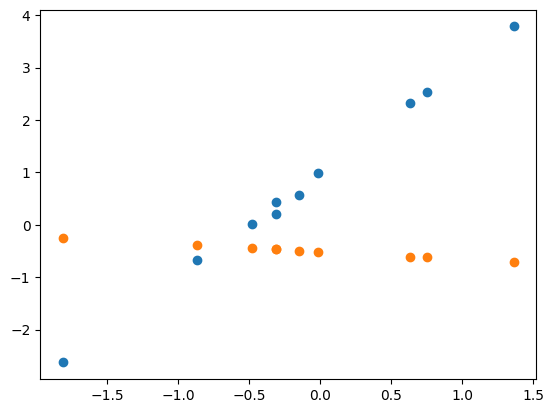

In [5]:
# EPOCH (first one!)
#Predict Y_hat and measure the Dtesp-Delta!!!

Y_hat = X @ W_predicted + b_predicted
# print("y_hat= ", Y_hat)
# print("y_true= ", Y_true)
step_delta = Y_true - Y_hat
# print("step_delta= ", step_delta)
print("          X       Y_true     Y_Hat    Step_delta   ")
print(torch.cat((X, Y_true, Y_hat, step_delta), dim=1))

# Loss function == MSE
#mse = (step_delta ** 2).mean()
rmse = (step_delta ** 2).mean().sqrt()
print("RMSE= ", rmse.item())
#print("MSE= ", mse.item())

rmse.backward(create_graph=True, retain_graph=True)
print("W_predicted= ", W_predicted.item())
print("b_predicted= ", b_predicted.item())
print("W_Grad=", W_predicted.grad.item())
print("b_Grad=", b_predicted.grad.item())

# Make sure to reset grads before next iteration!
W_predicted.grad.zero_()
b_predicted.grad.zero_()

# jUST like the transpose of above.
# print(torch.stack((X, Y_true, Y_hat, step_delta), dim=1))

# Plot
## Clone Tensor for plotting, Else:
## ERROR: RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
## WARN: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor)
#Y_hat_plot = torch.tensor(Y_hat)
Y_hat_plot = Y_hat.clone().detach()

plt.scatter(x=X, y=Y_true, colorizer='r')
plt.scatter(x=X, y=Y_hat_plot, colorizer='y')
plt.plot()
pass

[]

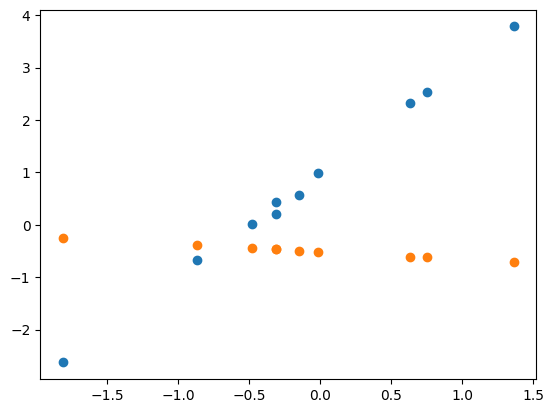

In [6]:
# Plot again
plt.scatter(x=X, y=Y_true, colorizer='r')
plt.scatter(x=X, y=Y_hat.detach(), colorizer='y')
plt.plot()


### Let's begin: The Neural Nets!

In [7]:


class MyNnLinearRegr(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.lin = nn.Linear(in_features, out_features)

    def forward(self, x):
        return self.lin(x)

    def extra_repr(self):
        super().extra_repr()

nn_model = MyNnLinearRegr(1, 1)
# nn_model.register_backward_hook(lambda x: print(" <<<< ", x))
print(nn_model)
print(list(nn_model.parameters()))
print(nn_model(X))



MyNnLinearRegr(
  (lin): Linear(in_features=1, out_features=1, bias=True)
)
[Parameter containing:
tensor([[-0.8629]], requires_grad=True), Parameter containing:
tensor([0.6544], requires_grad=True)]
tensor([[ 0.9239],
        [ 0.1113],
        [ 0.6694],
        [ 2.2172],
        [ 0.7842],
        [ 1.0665],
        [ 0.0084],
        [ 1.3993],
        [ 0.9241],
        [-0.5210]], grad_fn=<AddmmBackward0>)


In [8]:
from torch import optim

opti = optim.Adam(nn_model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
#loss_fn.register_backward_hook(lambda x: print(" >>>> ", x))

In [9]:
epochs = 10000

for epoch in range(epochs):
    Y_hat = nn_model(X)

    # The y_hat holds the refs of all the grad-tree
    # and now the loss is the new leaf of the grad-tree!
    # print(Y_hat)
    # print(Y_true)
    loss = loss_fn(Y_hat, Y_true)

    # Optimizer holds a ref to the nn_model.parameters()
    # Thus its able to reset the grads of the params (or the entire graph).
    opti.zero_grad()

    # Back propagate the error through the grad-tree
    loss.backward()

    # Opti knows what params to upgrade, using the corresponding grads
    opti.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs} >> loss: {loss.item():.4f}")
        print(f"Parameters: {list(nn_model.parameters())}")



Epoch 1/10000 >> loss: 5.9564
Parameters: [Parameter containing:
tensor([[-0.8529]], requires_grad=True), Parameter containing:
tensor([0.6444], requires_grad=True)]
Epoch 11/10000 >> loss: 5.5518
Parameters: [Parameter containing:
tensor([[-0.7531]], requires_grad=True), Parameter containing:
tensor([0.6623], requires_grad=True)]
Epoch 21/10000 >> loss: 5.1639
Parameters: [Parameter containing:
tensor([[-0.6539]], requires_grad=True), Parameter containing:
tensor([0.6749], requires_grad=True)]
Epoch 31/10000 >> loss: 4.7941
Parameters: [Parameter containing:
tensor([[-0.5559]], requires_grad=True), Parameter containing:
tensor([0.6873], requires_grad=True)]
Epoch 41/10000 >> loss: 4.4435
Parameters: [Parameter containing:
tensor([[-0.4594]], requires_grad=True), Parameter containing:
tensor([0.6995], requires_grad=True)]
Epoch 51/10000 >> loss: 4.1119
Parameters: [Parameter containing:
tensor([[-0.3647]], requires_grad=True), Parameter containing:
tensor([0.7114], requires_grad=True)]

In [10]:
# in_features and out_features both are 1, for our crafted data.
# Definitions & Overriding
from torch.nn import Module
from torch.nn import RNN
from torch.nn import ReLU
from torch.nn import GELU

lin = torch.nn.Linear(in_features=1, out_features=1, bias=True, dtype=torch.float32)
print(lin)

Linear(in_features=1, out_features=1, bias=True)


#### Plot

[]

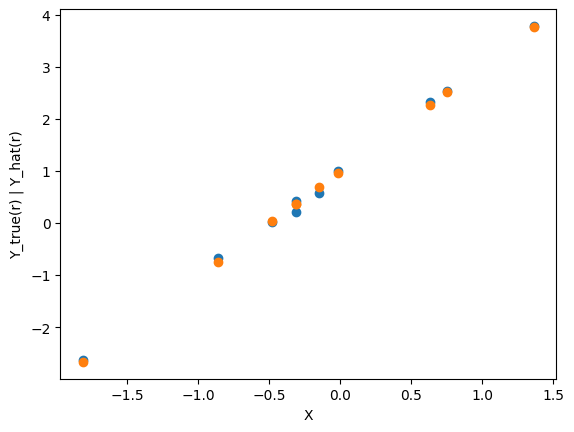

In [11]:
# Now plot
plt.xlabel('X')
plt.ylabel('Y_true(r) | Y_hat(r)')
plt.scatter(x=X, y=Y_true, colorizer='r')
plt.scatter(x=X, y=Y_hat.detach(), colorizer='')
plt.plot()